# AutoCompose

## Import Section

In [58]:
import os
os.chdir("C:/Users/KTS-WS-2501/Documents/Composer-py")
os.getcwd()

'C:\\Users\\KTS-WS-2501\\Documents\\Composer-py'

In [59]:
import torch
torch.manual_seed(64)

In [60]:
import json
import os
import time
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [61]:
from torch.optim import AdamW
from torch.utils.data import Dataset, random_split, DataLoader, RandomSampler, SequentialSampler
from transformers import GPT2LMHeadModel, GPT2Tokenizer, get_linear_schedule_with_warmup, DataCollatorWithPadding

## GPU Check

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [63]:
torch.cuda.mem_get_info(device=0)

(1222639616, 6438780928)

In [64]:
print(f"Device name: {torch.cuda.get_device_name(0)}")
props = torch.cuda.get_device_properties(0)
print(f"Total Memory (GB): {props.total_memory / 1024 ** 3}")

Device name: NVIDIA GeForce RTX 4050 Laptop GPU
Total Memory (GB): 5.99658203125


In [65]:
print(f"Allocated: {torch.cuda.memory_allocated() / 1024 ** 3}GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024 ** 3}GB")

Allocated: 1.7406740188598633GB
Reserved: 3.78515625GB


## Load tokenizer and model

In [66]:
model_name = "gpt2"

In [67]:
bos_token = "<|startoftext|>"
eos_token = "<|endoftext|>"
pad_token = "<|pad|>"

In [68]:
# tokenizer = GPT2Tokenizer.from_pretrained(
#     model_name, 
#     bos_token=bos_token, 
#     eos_token=eos_token, 
#     pad_token=pad_token
# )

In [69]:
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11765.45it/s]


In [127]:
tokenizer.bos_token = "<|startoftext|>"

In [128]:
tokenizer.pad_token = tokenizer.eos_token

In [129]:
tokenizer.bos_token_id

50256

In [130]:
tokenizer.special_tokens_map

{'bos_token': '<|startoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '<|endoftext|>'}

In [132]:
len(tokenizer)

50257

In [131]:
model.config.eos_token_id

50256

In [74]:
print(model.transformer.wte.weight.shape)

torch.Size([50257, 768])


In [75]:
print(model.get_input_embeddings().weight.shape)

torch.Size([50257, 768])


In [76]:
len(tokenizer)

50257

In [133]:
model.config.vocab_size

50257

In [134]:
model.resize_token_embeddings(len(tokenizer))

Embedding(50257, 768)

In [79]:
model = model.to(device)

## Data Preparation

In [80]:
data_dir = "data"
file_path = "anticipation.json"

In [81]:
file_full_path = os.path.normpath(os.path.join(data_dir,file_path))

In [82]:
with open(file_full_path, "r") as f:
    data = json.load(f)

data[:5]

[{'poem': 'Though the birds sang gayly to him,\nThough the wild-flowers of the meadow\nFilled the air with odors for him;\nThough the forests and the rivers\nSang and shouted at his coming,\nStill his heart was sad within him,\nFor he was alone in heaven.',
  'id': 26},
 {'poem': 'Rise up from your bed of branches,\nRise, O youth, and wrestle with me!"\nFaint with famine, Hiawatha\nStarted from his bed of branches,\nFrom the twilight of his wigwam\nForth into the flush of sunset\nCame, and wrestled with Mondamin;\nAt his touch he felt new courage\nThrobbing in his brain and bosom,\nFelt new life and hope and vigor\nRun through every nerve and fibre.',
  'id': 93},
 {'poem': 'On the morrow and the next day,\nWhen the sun through heaven descending,\nLike a red and burning cinder\nFrom the hearth of the Great Spirit,\nFell into the western waters,\nCame Mondamin for the trial,\nFor the strife with Hiawatha;\nCame as silent as the dew comes,\nFrom the empty air appearing,\nInto empty air r

In [83]:
data[0].keys()

dict_keys(['poem', 'id'])

Size of dataset

In [84]:
print(f"Train samples len: {len(data)}")

Train samples len: 28956


Check dataset

In [85]:
for i in range(3):
    print(data[i])

{'poem': 'Though the birds sang gayly to him,\nThough the wild-flowers of the meadow\nFilled the air with odors for him;\nThough the forests and the rivers\nSang and shouted at his coming,\nStill his heart was sad within him,\nFor he was alone in heaven.', 'id': 26}
{'poem': 'Rise up from your bed of branches,\nRise, O youth, and wrestle with me!"\nFaint with famine, Hiawatha\nStarted from his bed of branches,\nFrom the twilight of his wigwam\nForth into the flush of sunset\nCame, and wrestled with Mondamin;\nAt his touch he felt new courage\nThrobbing in his brain and bosom,\nFelt new life and hope and vigor\nRun through every nerve and fibre.', 'id': 93}
{'poem': 'On the morrow and the next day,\nWhen the sun through heaven descending,\nLike a red and burning cinder\nFrom the hearth of the Great Spirit,\nFell into the western waters,\nCame Mondamin for the trial,\nFor the strife with Hiawatha;\nCame as silent as the dew comes,\nFrom the empty air appearing,\nInto empty air returning,

Verify Tokenization

In [86]:
sample = data[0]['poem']
print(f"Sample data: {sample}")
sample_ids = tokenizer.encode(sample)
print(f"Sample text ids: {sample_ids}")
sample_decoded = tokenizer.decode(sample_ids)
print(f"Tokenizer decoded: {sample_decoded}")
print(f"Verify tokenizer: {sample == sample_decoded}")

Sample data: Though the birds sang gayly to him,
Though the wild-flowers of the meadow
Filled the air with odors for him;
Though the forests and the rivers
Sang and shouted at his coming,
Still his heart was sad within him,
For he was alone in heaven.
Sample text ids: [10915, 262, 10087, 25889, 5650, 306, 284, 683, 11, 198, 10915, 262, 4295, 12, 2704, 3618, 286, 262, 502, 4584, 198, 37, 2967, 262, 1633, 351, 16298, 669, 329, 683, 26, 198, 10915, 262, 17039, 290, 262, 18180, 198, 50, 648, 290, 17293, 379, 465, 2406, 11, 198, 9590, 465, 2612, 373, 6507, 1626, 683, 11, 198, 1890, 339, 373, 3436, 287, 9538, 13]
Tokenizer decoded: Though the birds sang gayly to him,
Though the wild-flowers of the meadow
Filled the air with odors for him;
Though the forests and the rivers
Sang and shouted at his coming,
Still his heart was sad within him,
For he was alone in heaven.
Verify tokenizer: True


In [87]:
tokenizer("hello",truncation=True,max_length=10,padding="max_length")

{'input_ids': [31373, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256], 'attention_mask': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [88]:
tokenizer.eos_token

'<|endoftext|>'

In [89]:
class PoemDataLoader(Dataset):
    def __init__(self, poems, tokenizer, max_len=512):
        self.attn_mask = []
        self.input_ids = []

        for poem in poems:
            
            encodings_dict = tokenizer("<|startoftext|>"+poem+"<|endoftext|>",max_length=512,truncation=True,padding=False) 
            self.input_ids.append(torch.tensor(encodings_dict["input_ids"]))
            self.attn_mask.append(torch.tensor(encodings_dict["attention_mask"]))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self,idx):
        return {"input_ids": self.input_ids[idx], "attention_mask":self.attn_mask[idx]}

In [90]:
poems_text = [poem["poem"] for poem in data]
len(poems_text)

28956

In [91]:
poem_data_loader = PoemDataLoader(poems=poems_text,max_len=256,tokenizer=tokenizer)

In [92]:
for d in poem_data_loader:
    print(d)
    break

{'input_ids': tensor([   27,    91,  9688,  1659,  5239,    91,    29, 10915,   262, 10087,
        25889,  5650,   306,   284,   683,    11,   198, 10915,   262,  4295,
           12,  2704,  3618,   286,   262,   502,  4584,   198,    37,  2967,
          262,  1633,   351, 16298,   669,   329,   683,    26,   198, 10915,
          262, 17039,   290,   262, 18180,   198,    50,   648,   290, 17293,
          379,   465,  2406,    11,   198,  9590,   465,  2612,   373,  6507,
         1626,   683,    11,   198,  1890,   339,   373,  3436,   287,  9538,
           13, 50256]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [93]:
lengths = []

for poem_data in poem_data_loader:
    length = poem_data["attention_mask"].sum().item()
    lengths.append(length)

print(lengths)
print(f"Min length : {min(lengths)}")
print(f"Max length : {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.2f}")

[72, 113, 117, 213, 87, 100, 160, 229, 89, 66, 101, 68, 57, 72, 137, 92, 260, 31, 89, 31, 141, 83, 73, 115, 91, 129, 34, 151, 34, 157, 269, 143, 55, 180, 151, 95, 237, 78, 93, 419, 100, 164, 63, 409, 41, 161, 200, 56, 72, 98, 81, 179, 105, 258, 244, 163, 333, 48, 107, 117, 120, 132, 68, 221, 466, 77, 91, 220, 131, 131, 93, 51, 121, 57, 186, 92, 83, 45, 165, 276, 356, 45, 55, 64, 319, 512, 93, 178, 59, 48, 191, 95, 182, 342, 89, 113, 89, 97, 84, 128, 389, 75, 42, 197, 54, 71, 89, 92, 160, 121, 156, 102, 250, 233, 70, 154, 148, 299, 131, 48, 266, 107, 125, 95, 434, 85, 213, 325, 49, 114, 195, 117, 44, 152, 139, 338, 246, 43, 135, 55, 49, 203, 148, 143, 65, 183, 141, 93, 39, 102, 143, 399, 57, 41, 72, 182, 57, 202, 464, 105, 125, 120, 48, 53, 190, 121, 332, 305, 60, 46, 71, 56, 270, 84, 40, 39, 95, 75, 166, 42, 111, 46, 65, 84, 154, 105, 52, 50, 43, 131, 31, 43, 127, 54, 59, 88, 41, 38, 53, 50, 42, 40, 43, 50, 38, 40, 41, 45, 42, 42, 44, 74, 89, 44, 90, 41, 171, 81, 47, 88, 66, 192, 76, 9

In [94]:
lengths = np.array(lengths)

print("P50:", np.percentile(lengths, 50))
print("P90:", np.percentile(lengths, 90))
print("P95:", np.percentile(lengths, 95))
print("P99:", np.percentile(lengths, 99))

P50: 73.0
P90: 185.0
P95: 253.0
P99: 463.4500000000007


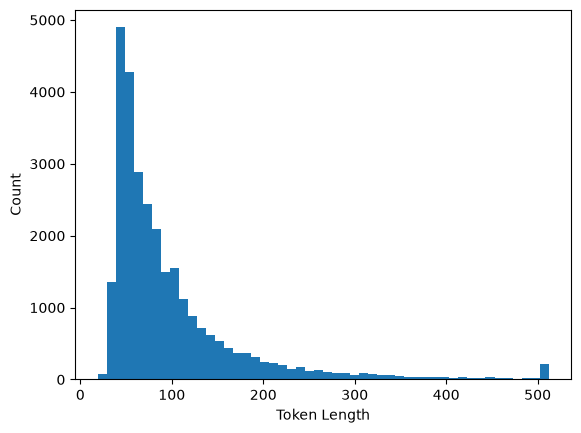

In [95]:
plt.hist(lengths, bins=50)
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.show()

In [96]:
epochs = 1
warmup_steps = 1e2
sample_every = 100
batch_size = 4
gradient_accumulation_steps = 16

In [97]:
train_size = int(0.95 * len(data))
val_size = len(data) - train_size

In [98]:
train_data, val_data = random_split(poem_data_loader,[train_size, val_size])

In [ ]:
data_collector = DataCollatorWithPadding(tokenizer=tokenizer,pad_to_multiple_of=8)

In [100]:
for d in train_data:
    print(d)
    break

{'input_ids': tensor([   27,    91,  9688,  1659,  5239,    91,    29,  1890, 21682,  2236,
         9629,   262, 20354,   757,    26,   198, 15316,   262,   698,   436,
         1586,  3687,  2236,  6611,   438,   198,  1199,  1901,   257,  2330,
        20218,   395,   832,   262,  1278,   268,    11,   198,  1870,  3440,
          262,   279,  1127,   351,  6729,    13, 50256]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [101]:
train_data_loader = DataLoader(train_data, batch_size=batch_size, sampler=RandomSampler(train_data),collate_fn=data_collector)
val_data_loader = DataLoader(val_data, batch_size=batch_size, sampler=SequentialSampler(val_data),collate_fn=data_collector)

In [102]:
train_data_loader

In [103]:
optimizer = AdamW(model.parameters(), lr=5e-5, eps=1e-8)
total_training_steps = len(train_data_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer=optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_training_steps)

In [104]:
def format_time(elapsed):
  return str(datetime.timestamp(seconds=int(round(elapsed))))

In [105]:
model.config.vocab_size

50257

In [106]:
print("Tokenizer size:", len(tokenizer))
print("Model vocab size:", model.config.vocab_size)

sample = poem_data_loader.input_ids[0]
print(max(sample))

Tokenizer size: 50257
Model vocab size: 50257
tensor(50256)


In [107]:
for step, batch in enumerate(train_data_loader):
    print(batch)
    break


{'input_ids': tensor([[   27,    91,  9688,  1659,  5239,    91,    29, 23722,   339,    11,
          3025,  3173,   262,  5801, 31733, 11007,    11,   198, 24564,  4892,
           393,  4259,   530,  3356,   286,   465,  2000,    30,   198,  8241,
          2497,   663, 12252,   994,  4485,    11,   290,   612, 15350,    11,
           198, 18438,   391,   465,   898,  3726,    11,   393,   465,   886,
            30,   198,  2348,   292,    11,   644,  4240,     0,   582,   338,
          9098,   636,   198,  3118, 26752,   743,  4485,    11,   290, 12080,
           422,  1242,   284,  1242,    26,   198,  1537,   618,   465,   898,
          1049,   670,   318,   475,  9258,    11,   198,  2061,  1738,   356,
          3080,    11,   416,  7506,   318, 45171,    13, 50256, 50256, 50256,
         50256, 50256, 50256, 50256],
        [   27,    91,  9688,  1659,  5239,    91,    29,  1870,   422,   511,
         20237,   262,  9896,  8278,    11,   290,   836,    77,  1549,   198,


In [108]:
print("Embedding vocab:",
      model.get_input_embeddings().num_embeddings)

Embedding vocab: 50257


In [109]:
for step, batch in enumerate(train_data_loader):
        b_input_ids = batch["input_ids"].to(device)
        b_labels = batch["input_ids"].to(device)
        b_masks = batch["attention_mask"].to(device)
        if b_input_ids.min().item() < 0:
            print(f"Step: {step}Min token:", b_input_ids.min().item())
        if b_input_ids.max().item() >= model.get_input_embeddings().num_embeddings:
            print(f"Step: {step}Max token:", b_input_ids.max().item())

In [110]:
model.config.n_positions

1024

Overfitting test

In [111]:

for step, batch in enumerate(train_data_loader):
    b_input_ids = batch["input_ids"].to(device)
    b_labels[b_masks == 0] = -100
    b_labels = batch["input_ids"].to(device)
    b_masks = batch["attention_mask"].to(device)
    break

In [113]:
tokenizer.decode(batch["input_ids"])

["<|startoftext|>No sudden thing of glory and fear\nWas the Lord's coming; but the dear\nSlow Nature's days followed each other\nTo form the Saviour from his Mother\n--One of the children of the year.<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof

In [ ]:
# for epoch in range(1000):
#     outputs = model(b_input_ids,labels=b_labels,attention_mask=b_masks)
#     loss = outputs[0]
#     print(f"For epoch: {epoch} loss is: {loss}")
#     loss.backward()
#     optimizer.step()
#     scheduler.step()
#     optimizer.zero_grad()


For epoch: 0 loss is: 9.23483657836914
For epoch: 1 loss is: 9.23483657836914
For epoch: 2 loss is: 9.206822395324707
For epoch: 3 loss is: 9.150834083557129
For epoch: 4 loss is: 9.066530227661133
For epoch: 5 loss is: 8.953595161437988
For epoch: 6 loss is: 8.811351776123047
For epoch: 7 loss is: 8.638958930969238
For epoch: 8 loss is: 8.43510627746582
For epoch: 9 loss is: 8.197959899902344
For epoch: 10 loss is: 7.925008296966553
For epoch: 11 loss is: 7.612940311431885
For epoch: 12 loss is: 7.257564067840576
For epoch: 13 loss is: 6.8539838790893555
For epoch: 14 loss is: 6.397340297698975
For epoch: 15 loss is: 5.885251522064209
For epoch: 16 loss is: 5.325713157653809
For epoch: 17 loss is: 4.75813627243042
For epoch: 18 loss is: 4.254377841949463
For epoch: 19 loss is: 3.837841749191284
For epoch: 20 loss is: 3.469667911529541
For epoch: 21 loss is: 3.113349199295044
For epoch: 22 loss is: 2.765204668045044
For epoch: 23 loss is: 2.4522929191589355
For epoch: 24 loss is: 2.206

KeyboardInterrupt: 

In [ ]:
for epoch in range(epochs):
    t0 = time.perf_counter()
    total_train_loss = 0
    model.train()

    for step, batch in enumerate(train_data_loader):
        if step % gradient_accumulation_steps == 0:
            optimizer.zero_grad()
        b_input_ids = batch["input_ids"].to(device)
        b_labels[b_masks == 0] = -100
        b_labels = batch["input_ids"].to(device)
        b_masks = batch["attention_mask"].to(device)
        outputs = model(b_input_ids, labels=b_labels, attention_mask=b_masks)

        loss = outputs[0]
        loss = loss / gradient_accumulation_steps
        loss.backward()

        batch_loss = loss.item()
        total_train_loss += batch_loss

        if (step + 1) % sample_every == 0:
            elapsed = time.perf_counter() - t0
            print(f"Batch {step} of {len(train_data_loader)}. Loss: {batch_loss}. Time: {elapsed}")

        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(train_data_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0,foreach=True)
            optimizer.step()
            scheduler.step()


Batch 99 of 6877. Loss: 0.18772540986537933. Time: 85.39534500000082
Batch 199 of 6877. Loss: 0.166158527135849. Time: 162.13964710000073
Batch 299 of 6877. Loss: 0.09549898654222488. Time: 243.21908229999826
Batch 399 of 6877. Loss: 0.1632089465856552. Time: 324.55577840000115
Batch 499 of 6877. Loss: 0.18500153720378876. Time: 418.19154100000014
Batch 599 of 6877. Loss: 0.16399283707141876. Time: 498.49676460000046
Batch 699 of 6877. Loss: 0.11195513606071472. Time: 589.5635398999984
Batch 799 of 6877. Loss: 0.1513260453939438. Time: 669.0228833000001
Batch 899 of 6877. Loss: 0.15878315269947052. Time: 757.0764096999992
Batch 999 of 6877. Loss: 0.0998830795288086. Time: 865.2638922000006
Batch 1099 of 6877. Loss: 0.09665023535490036. Time: 960.7631591999998
Batch 1199 of 6877. Loss: 0.12694747745990753. Time: 1060.1857963000002
Batch 1299 of 6877. Loss: 0.16750305891036987. Time: 1152.100684099998
Batch 1399 of 6877. Loss: 0.08522115647792816. Time: 1245.3929643999982


KeyboardInterrupt: 

In [ ]:
total_time_taken = time.perf_counter() - t0
f"Total time taken: {total_time_taken}"

'Total time taken: 1253.557718699998'

In [ ]:
sample_id = torch.randint(low=0, high=512, size=(1,168)).to(device=device)
sample_id

tensor([[294, 259, 239, 316, 115, 193, 476, 486, 327, 320, 113, 433, 302, 122,
         410, 400, 411, 118,  30, 326,  96,  23, 147, 480,  33, 452, 199, 283,
         474, 484, 334, 130, 119, 136, 104,   8, 225,  44,  96, 262,  97, 359,
          69, 473, 109,  51,  37, 192, 386,  14,   3, 452, 319, 313, 190, 348,
         167, 450, 182,  91, 157, 471, 338, 260, 462, 202, 340, 300, 214, 258,
         358, 436, 277, 350, 137, 299, 182,  71, 289,  37, 359, 392, 472,  96,
          99, 208, 194, 366, 490, 176, 496, 311, 302,   7, 452,  61,  51,  26,
         159,  23, 478,  95,  74,  54, 458, 158, 483, 174, 350, 400,  38, 145,
          22, 335, 163, 392, 120,  32,  74,  34, 372, 235,  79, 379, 169, 112,
         174, 116, 368, 143, 190, 431,  78, 329, 267, 457, 133, 392, 302, 428,
         307, 227,  70, 110, 267, 417, 320,  12, 222, 179, 183, 511, 106, 434,
         364, 392, 396, 422,  52,  37, 128, 359, 410,  24,   2, 492,  15, 457]],
       device='cuda:0')

In [ ]:
tokenizer.decode(sample_id)

[' thin�et�\x05 wor01 Cim�art re� vthres�? that�8�ameBiv\x0bar j they uƻ̫)�M� the�illf sa�TF\x04 pro/$iv onot\x02 wh� ab�|� U\'sreome\x0e it l\x1ahendust f P� n�h hFillandrou��\x14\x06 "ther�age S re(iv^T;�8ect�kW pl� whe� PthG�7ld�and�AkCher�p at���em�\x02peo for opt�and re this be�g� oelim-��� their�mentersandist fromUF�ill v9#..0pt']

In [ ]:
model.eval()
sample_out = model(sample_id)
sample_out

CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[-1.6590e+02, -1.6288e+02, -1.6802e+02,  ..., -2.0064e+02,
          -1.9607e+02, -1.7149e+02],
         [-4.2679e+00, -4.0450e+00, -9.7751e+00,  ..., -1.4814e+01,
          -1.0334e+01, -5.3560e+00],
         [-6.2805e+00, -5.6636e+00, -9.9564e+00,  ..., -1.6516e+01,
          -1.2250e+01, -7.1295e+00],
         ...,
         [-1.4091e-01,  2.1013e+00,  1.7278e+00,  ..., -7.2100e+00,
          -8.3431e+00,  7.2855e+00],
         [-4.6548e+00, -3.9265e+00, -2.3712e+00,  ..., -1.2486e+01,
          -1.3995e+01, -2.9678e+00],
         [ 9.3976e-01,  9.6198e-01,  1.4650e+00,  ..., -6.0850e+00,
          -6.6677e+00,  2.0096e+00]]], device='cuda:0',
       grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None, cr

In [ ]:
sample_out.logits.shape

torch.Size([1, 168, 50257])

In [ ]:
torch.argmax(sample_out.logits[:,-1,:],dim=-1)

tensor([13], device='cuda:0')

In [ ]:
tokenizer.decode(torch.argmax(sample_out.logits[:,-1,:],dim=-1))

'.'

In [115]:
def generate(text: str, max_output_num=10):
    end_of_text_id = 50256
    tokenizer_output = tokenizer(text)
    input_ids = torch.tensor([tokenizer_output["input_ids"]]).to(device)
    for _ in range(max_output_num):
        next_token_output = model(input_ids)
        next_token_logits = next_token_output.logits[:,-1,:]
        next_token_id = torch.argmax(next_token_logits,dim=-1).reshape(1,-1)
        if next_token_id == end_of_text_id:
            break
        input_ids = torch.cat((input_ids,next_token_id),dim=-1)

    full_text = tokenizer.decode(input_ids)
    return full_text

In [117]:
tokenizer.decode(batch["input_ids"])

["<|startoftext|>No sudden thing of glory and fear\nWas the Lord's coming; but the dear\nSlow Nature's days followed each other\nTo form the Saviour from his Mother\n--One of the children of the year.<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof

In [ ]:
generate("Who are you?",max_output_num=100)

["Who are you?\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI'm a little girl,\nI"]